In [25]:
# 1. Import et chargement du dataset Boston Housing
from tensorflow.keras.datasets import boston_housing

# Charge les données : x* contiennent les caractéristiques, y* la cible (prix)
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

# Vérification des dimensions
print("x_train :", x_train.shape)
print("y_train :", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_train : (404, 13)
y_train : (404,)
x_test : (102, 13)
y_test : (102,)


In [26]:
import numpy as np

# Calcul de la moyenne et de l'écart-type sur l'ensemble d'entraînement
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

# Application de la normalisation (z-score)
x_train_norm = (x_train - mean) / std
x_test_norm = (x_test - mean) / std

# Vérifie quelques statistiques
print("Moyenne après normalisation (train) :", np.mean(x_train_norm, axis=0)[:5])
print("Écart-type après normalisation (train) :", np.std(x_train_norm, axis=0)[:5])

Moyenne après normalisation (train) : [-1.01541438e-16  1.09923072e-17  1.74337992e-15 -1.26686340e-16
 -5.25377321e-15]
Écart-type après normalisation (train) : [1. 1. 1. 1. 1.]


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Création d'un modèle séquentiel
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train_norm.shape[1],)),
    Dense(64, activation='relu'),  # Note: "relu" devrait être "relu"
    Dense(1)  # sortie : une seule valeur continue (prix)
])

# Affiche le résumé de l'architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# On choisit l'optimiseur, la fonction de perte et la métrique
model.compile(
    optimizer='adam',
    loss='mse',    # mean squared error pour la régression
    metrics=['mae']  # mean absolute error pour suivre l'erreur en unités de prix
)

In [29]:
# On réserve 20% des données d'entraînement pour la validation
history = model.fit(
    x_train_norm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 599.7057 - mae: 22.5381 - val_loss: 614.8815 - val_mae: 22.9900
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 533.6693 - mae: 21.1537 - val_loss: 572.8602 - val_mae: 22.0455
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 500.2361 - mae: 20.2126 - val_loss: 520.0397 - val_mae: 20.8189
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 442.2712 - mae: 18.8902 - val_loss: 449.7910 - val_mae: 19.1413
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 345.7819 - mae: 16.3611 - val_loss: 358.5872 - val_mae: 16.7529
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 294.3696 - mae: 14.7654 - val_loss: 250.9234 - val_mae: 13.5170
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 190.7216 - mae: 11.5189 - val_loss: 151.6275 - val_mae: 9.7205
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 104.1140 - mae: 7.9913 - val_loss: 90.4913 - val_mae: 6.8971
Epoch 9/100
1

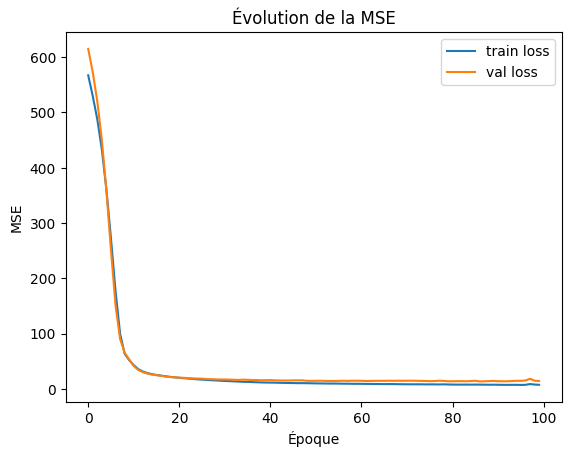

In [30]:
# Optionnel : tracer l'évolution de la perte et de la MAE
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.title("Évolution de la MSE")
plt.xlabel("Époque")
plt.ylabel("MSE")
plt.legend()
plt.show()

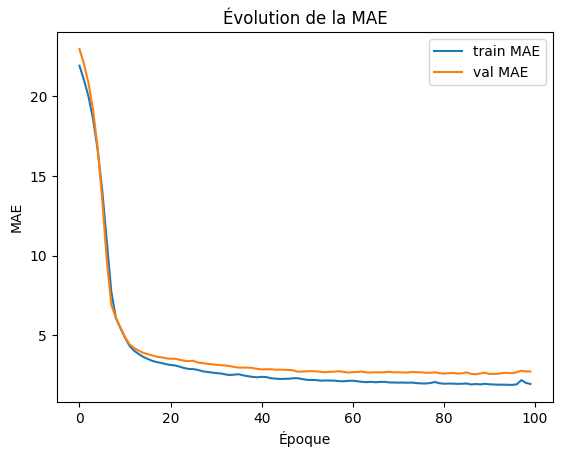

In [31]:
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.title("Évolution de la MAE")
plt.xlabel("Époque")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [32]:
test_loss, test_mae = model.evaluate(x_test_norm, y_test, verbose=1)

print(f"Test MSE : {test_loss:.3f}, Test MAE : {test_mae:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.5511 - mae: 2.8671
Test MSE : 25.485, Test MAE : 3.065


In [33]:
# Choisit un exemple du jeu de test
sample = x_test_norm[0:1]  # Format batch (1 échantillon)
vrai_prix = y_test[0]

# Prédiction
pred = model.predict(sample)[0][0]  # Extraction de la valeur scalaire

print(f"Prix prédit : {pred:.2f} milliers $")
print(f"Prix réel   : {vrai_prix:.2f} milliers $")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Prix prédit : 6.45 milliers $
Prix réel   : 7.20 milliers $
